--- DATASET SUMMARY ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mean radius   569 non-null    float64
 1   mean texture  569 non-null    float64
 2   Target        569 non-null    int64  
 3   Class         569 non-null    object 
dtypes: float64(2), int64(1), object(1)
memory usage: 17.9+ KB
None

--- STATISTICAL OVERVIEW ---
       mean radius  mean texture      Target
count   569.000000    569.000000  569.000000
mean     14.127292     19.289649    0.254833
std       3.524049      4.301036    0.967836
min       6.981000      9.710000   -1.000000
25%      11.700000     16.170000   -1.000000
50%      13.370000     18.840000    1.000000
75%      15.780000     21.800000    1.000000
max      28.110000     39.280000    1.000000

--- CLASS DISTRIBUTION ---
Class
Benign (+1)       357
Malignant (-1)    212
Name: count, dtype: int64


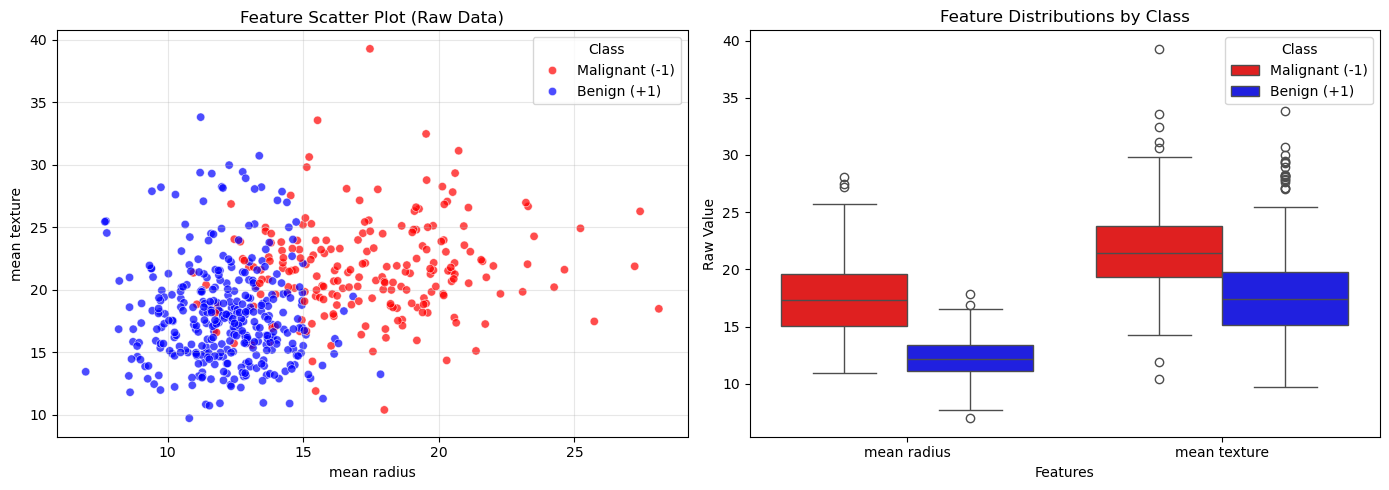

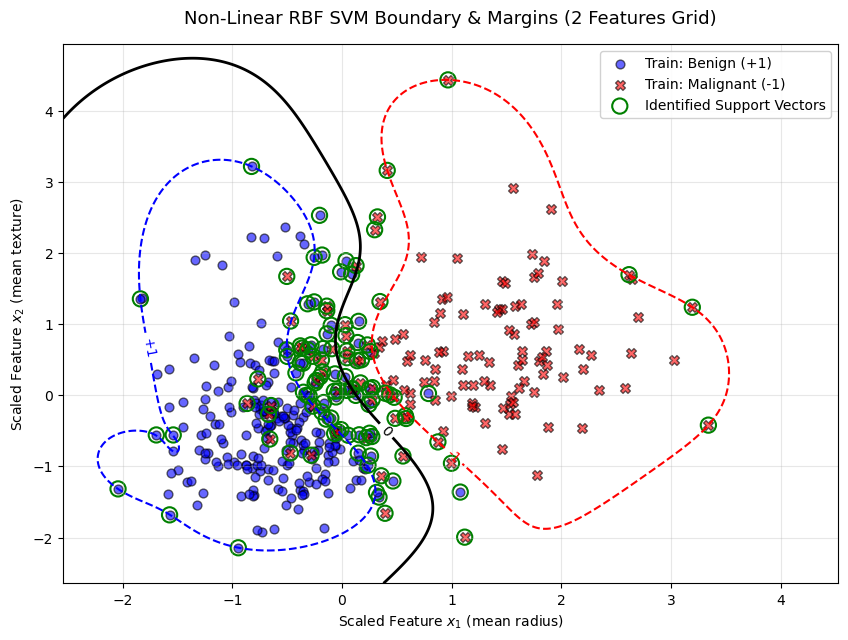

<Figure size 600x500 with 0 Axes>

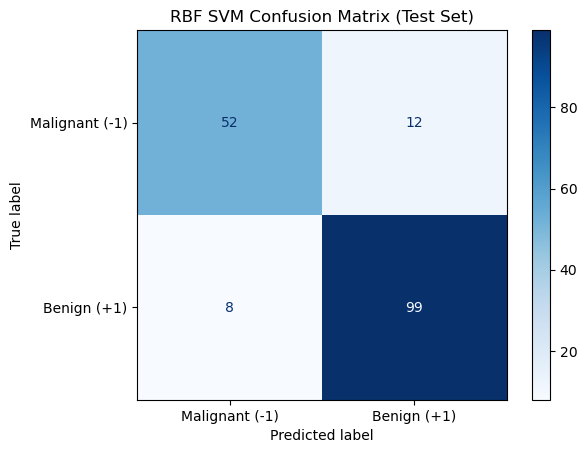

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# ==========================================
# 1. Load Dataset & Setup
# ==========================================
data = load_breast_cancer()
# Using the 2 features specified in the original request
X = data.data[:, [0, 1]]  # 'mean radius', 'mean texture'
y = data.target

# Convert labels from {0, 1} to {-1, +1} to match margin concepts
y_transformed = np.where(y == 0, -1, 1)

# Create a DataFrame for cleaner EDA operations
df = pd.DataFrame(X, columns=[data.feature_names[0], data.feature_names[1]])
df["Target"] = y_transformed
df["Class"] = df["Target"].map({1: "Benign (+1)", -1: "Malignant (-1)"})

# ==========================================
# 2. Exploratory Data Analysis (EDA)
# ==========================================
print("--- DATASET SUMMARY ---")
print(df.info())
print("\n--- STATISTICAL OVERVIEW ---")
print(df.describe())

print("\n--- CLASS DISTRIBUTION ---")
print(df["Class"].value_counts())

# Plot EDA Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot of features
sns.scatterplot(
    data=df,
    x=data.feature_names[0],
    y=data.feature_names[1],
    hue="Class",
    palette={"Benign (+1)": "blue", "Malignant (-1)": "red"},
    alpha=0.7,
    ax=axes[0],
)
axes[0].set_title("Feature Scatter Plot (Raw Data)")
axes[0].grid(True, alpha=0.3)

# Boxplots to check for separability and outliers
df_melted = pd.melt(
    df,
    id_vars=["Class"],
    value_vars=[data.feature_names[0], data.feature_names[1]],
)
sns.boxplot(
    data=df_melted,
    x="variable",
    y="value",
    hue="Class",
    palette={"Benign (+1)": "blue", "Malignant (-1)": "red"},
    ax=axes[1],
)
axes[1].set_title("Feature Distributions by Class")
axes[1].set_xlabel("Features")
axes[1].set_ylabel("Raw Value")
plt.tight_layout()
plt.show()

# ==========================================
# 3. Train / Test Split & Feature Scaling
# ==========================================
# Split data to properly evaluate model with a Confusion Matrix later
X_train, X_test, y_train, y_test = train_test_split(
    X, y_transformed, test_size=0.3, random_state=42, stratify=y_transformed
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Scale full set just for full decision boundary visualization plotting
X_scaled_full = scaler.transform(X)

# ==========================================
# 4. Train Non-Linear SVM (RBF Kernel)
# ==========================================
# Using RBF kernel for non-linear decision mapping
model = SVC(kernel="rbf", C=1.5, gamma="scale")
model.fit(X_train_scaled, y_train)

# ==========================================
# 5. Non-Linear Decision Boundary Plotting
# ==========================================
# Setup grid limits based on scaled data
x1_min, x1_max = (
    X_scaled_full[:, 0].min() - 0.5,
    X_scaled_full[:, 0].max() + 0.5,
)
x2_min, x2_max = (
    X_scaled_full[:, 1].min() - 0.5,
    X_scaled_full[:, 1].max() + 0.5,
)

xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 500), np.linspace(x2_min, x2_max, 500)
)

# Compute the decision function values across our mesh grid
# This replaces the linear algebraic manual formulas
Z = model.decision_function(np.c_[xx1.ravel(), xx2.ravel()])
Z = Z.reshape(xx1.shape)

plt.figure(figsize=(10, 7))

# Plot the Non-linear Decision Boundary (0) and Margins (-1, 1) using contours
contour = plt.contour(
    xx1,
    xx2,
    Z,
    levels=[-1, 0, 1],
    linestyles=["--", "-", "--"],
    colors=["red", "black", "blue"],
    linewidths=[1.5, 2, 1.5],
)
plt.clabel(contour, inline=True, fontsize=10, fmt={-1: "-1", 0: "0", 1: "+1"})

# Plot training points
plt.scatter(
    X_train_scaled[y_train == 1, 0],
    X_train_scaled[y_train == 1, 1],
    color="blue",
    s=40,
    edgecolors="k",
    alpha=0.6,
    label=f"Train: Benign (+1)",
)
plt.scatter(
    X_train_scaled[y_train == -1, 0],
    X_train_scaled[y_train == -1, 1],
    color="red",
    marker="X",
    s=50,
    edgecolors="k",
    alpha=0.6,
    label=f"Train: Malignant (-1)",
)

# Highlight Support Vectors
support_vectors = model.support_vectors_
plt.scatter(
    support_vectors[:, 0],
    support_vectors[:, 1],
    s=120,
    facecolors="none",
    edgecolors="green",
    lw=1.5,
    label="Identified Support Vectors",
)

plt.xlim(x1_min, x1_max)
plt.ylim(x2_min, x2_max)
plt.xlabel(f"Scaled Feature $x_1$ ({data.feature_names[0]})")
plt.ylabel(f"Scaled Feature $x_2$ ({data.feature_names[1]})")
plt.title(
    "Non-Linear RBF SVM Boundary & Margins (2 Features Grid)",
    fontsize=13,
    pad=15,
)
plt.legend(loc="upper right", framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================
# 6. Confusion Matrix Evaluation
# ==========================================
predictions = model.predict(X_test_scaled)
cm = confusion_matrix(y_test, predictions, labels=[-1, 1])

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Malignant (-1)", "Benign (+1)"]
)
disp.plot(cmap="Blues", values_format="d")
plt.title("RBF SVM Confusion Matrix (Test Set)")
plt.show()
